# COGS 108 - EDA Checkpoint

## Authors

Example team list and credits:
- Shaila Valenzuela : dataset cleaning, EDA dataset #1
- Nicholas Nurwinata : dataset cleaning
- Khuyen Lai
- Weng Lok

# Research Question

How do student demographics, study habits, and non-academic behaviors relate to academic performance (e.g., semester grades) in a recent higher-education context? Specifically, which factors (attendance, study preparation time, gaming habits, family income, etc.) are most predictive of a student’s final GPA, and can we build a predictive model that outperforms a simple baseline? This is a regression problem where the outcome variable will be GPA or equivalent grade metrics, and predictors include socio-economic and behavior attributes. The research will include controlling for confounders such as department/major and gender. It will explore both statistical significance of variables and predictive power via machine learning models.

## Background and Prior Work

Academic performance in higher education is influenced by a mix of student habits, demographic characteristics, and lifestyle behaviors. We define academic success using quantitative measures such as GPA or final course grades. GPA is not only important within the academic environment but is also connected to future opportunities such as graduate school admissions and job offers. Employer surveys indicate that GPA has historically been used as an initial screening tool in entry-level hiring, meaning that stronger academic performance can increase access to early career opportunities, even as some employers shift toward skills-based hiring practices ([NACE, 2023](https://www.naceweb.org/talent-acquisition/trends-and-predictions/nearly-two-thirds-of-employers-use-skills-based-hiring-practices-for-new-entry-level-hires?utm_source=chatgpt.com)). Understanding what influences academic performance may therefore help students improve both academic and post-graduate outcomes. Prior research suggests that both academic behaviors and non-academic factors, such as sleep patterns or leisure activities, play roles in shaping student outcomes, though the relative strength of these influences varies by context and population.

Studies have consistently shown that class attendance and engagement are strongly associated with higher academic achievement. Research across institutions has found that increased attendance reduces the likelihood of poor academic outcomes such as failing or withdrawing from courses, suggesting that attendance is a strong predictor of academic success ([Credé et al., 2010](https://files.eric.ed.gov/fulltext/EJ1248452.pdf)). In contrast, excessive video game use and screen time have been linked to lower GPA. Research examining video game usage among college students finds that higher levels of gaming are associated with reduced study time and weaker time management skills, which can negatively affect academic performance ([Anand, 2017](https://www.researchgate.net/publication/303226124_The_impact_of_video_games_on_student_GPA_study_habits_and_time_management_skills_What's_the_big_deal)).

Demographic and socioeconomic factors have also been associated with variation in academic performance. Research on socioeconomic status suggests that indicators such as family income and parental education are correlated with GPA, likely because these factors influence access to educational resources, academic support systems, and the amount of time students can devote to studying. These findings highlight the importance of considering both individual behaviors and background characteristics when modeling academic performance, as academic outcomes are shaped by structural as well as personal factors ([Credé et al., 2010](https://files.eric.ed.gov/fulltext/EJ1248452.pdf)).

Non-academic lifestyle factors, particularly sleep and time management, have also been identified as important predictors of academic performance. Studies of college students show that sleep duration and sleep quality are positively associated with GPA, while chronic sleep deprivation is linked to lower academic performance and increased academic stress ([Short et al., 2023](https://www.jahonline.org/article/S1054-139X(23)00373-7/fulltext)). Additionally, research comparing working and non-working students suggests that employment responsibilities can indirectly affect academic outcomes by reducing time available for sleep and study. Together, these findings suggest that lifestyle constraints outside the classroom can meaningfully influence academic success and should be accounted for in analyses of student performance.

# Hypothesis


We hypothesize that students with better academic habits, especially higher attendance and more consistent study time, will have higher grades. We also predict that non-academic behaviors that take time away from schoolwork, for example gaming time and alcohol use, will be negatively associated with GPA. For demographic/socioeconomic factors, we expect them to explain less variation in GPA than academic behaviors. Overall, we expect that a predictive model using these habit variables will show a simple baseline by meaningfully reducing prediction error and that attendance and study time will appear as the most important predictors across models.

## Data

### Data overview

Ideal dataset:
- Individual student records with GPA or final course grades
- Demographic features (gender, age, income, urban/rural status, major)
- Behavioural features (attendance rate, hours studied, hours gaming, part-time job status, extracurricular activities)
- Academic history (Highschool scores, prior GPA)
- Size, 5000+ records

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    {
        "url": "https://drive.google.com/uc?export=download&id=1jv0r6OsBZyt-nr2Sb9jtaAaxqI-OD0fP",
        "filename": "student-performance.csv",
    },
    {
        "url": "https://drive.google.com/uc?export=download&id=130iTt9KYDazxSX8UP-FCwq02D95auli2",
        "filename": "ai-impact-students-performance-dataset.csv",
    },
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:02<00:02,  2.13s/it]

Successfully downloaded: student-performance.csv


Overall Download Progress: 100%|██████████| 2/2 [00:04<00:00,  2.16s/it]

Successfully downloaded: ai-impact-students-performance-dataset.csv


In [4]:
%matplotlib inline 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols


### Dataset #1 

### Student Performance Dataset

**Source:** Kaggle – Student_performance_data  
https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

This dataset contains individual-level student records describing demographic characteristics, study habits, parental involvement, extracurricular participation, and academic performance. Each row represents one student, identified by a unique `StudentID` ranging from 1001 to 3392. The dataset includes approximately **2,392 student observations** and **15 variables**.

---

### Outcome Variable

The primary outcome variable for this project is:

- `GPA` — Grade Point Average on a scale from **2.0 to 4.0**. Higher values indicate stronger academic performance. GPA is influenced by study habits, parental involvement, and extracurricular engagement.

Although the dataset also includes `GradeClass`, which categorizes GPA into letter grades (A–F), we will model `GPA` as a **continuous variable** for regression analysis. Since `GradeClass` is derived directly from `GPA`, it will not be used as a predictor to avoid target leakage.

---

### Demographic Variables

These variables allow us to examine socioeconomic and demographic influences on academic performance:

- `Age` — 15–18 years  
- `Gender` — Binary encoded (0 = Male, 1 = Female)  
- `Ethnicity` — 0 = Caucasian, 1 = African American, 2 = Asian, 3 = Other  
- `ParentalEducation` — Highest parental education level:  
  - 0 = None  
  - 1 = High School  
  - 2 = Some College  
  - 3 = Bachelor’s  
  - 4 = Higher  

---

### Study Habits

These variables directly relate to our hypothesis that stronger academic habits predict higher GPA:

- `StudyTimeWeekly` — Weekly study time in hours (0–20 hours)  
- `Absences` — Number of absences during the school year (0–30)  
- `Tutoring` — Participation in tutoring (0 = No, 1 = Yes)  

---

### Parental Involvement

This variable evaluates whether family engagement contributes to student outcomes:

- `ParentalInvolvement` —  
  - 0 = None  
  - 1 = Low  
  - 2 = Moderate  
  - 3 = High  
  - 4 = Very High  

---

### Extracurricular Activities

These variables allow us to examine whether time spent outside academics relates to GPA. Each variable is binary (0 = No, 1 = Yes):

- `Extracurricular`  
- `Sports`  
- `Music`  
- `Volunteering`  

---

### Dataset Limitations & Concerns

- **Age Range (15–18 years):** The dataset appears to represent high school students rather than higher-education students. While our research question refers to higher education, this dataset still allows us to explore relationships between habits and academic performance in a structured academic environment.  

- **Self-Reported Behavior:** Study time and absences may be self-reported and subject to reporting bias.  

- **Categorical Encoding:** Several variables are numerically coded but represent categories. These must be treated as categorical variables during modeling to avoid incorrect assumptions of linear relationships.  

- **Derived Variable (`GradeClass`):** Because `GradeClass` is calculated directly from `GPA`, including both in modeling would introduce leakage. Therefore, `GPA` will be used as the regression outcome.

In [ ]:
df_raw = pd.read_csv('data/00-raw/Student_performance_data_.csv')
df = df_raw.copy()

print("First 5 rows")
display(df.head())

#Is the dataset tidy?
print("\nDataset shape:")
print("Rows (observations):", df.shape[0])
print("Columns (variables):", df.shape[1])

print("\nColumn names:")
print(df.columns)

#Missing data Analysis
missing_counts = df.isna().sum()
missing_percent = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count" : missing_counts,
    "Missing Percent" : missing_percent
})

print("\nMissing Data Summary:")
display(missing_summary)

# Suspicious Value Checks 
print("\nSummary statistics:")
display(df.describe())

print("\nChecking for impossible GPA values:")
display(df[(df["GPA"]<0) | (df["GPA"]>4)])

print("\nChecking for negative StudyTimeWeekly:")
display(df[df["StudyTimeWeekly"]<0])

print("\nChecking for negative Absences:")
display(df[df["Absences"]<0])

# Convert categorical vars
categorical_cols = [
    "Gender", "Ethnicity", "ParentalEducation",
    "Tutoring",  "ParentalSupport", 
    "Extracurricular", "Sports", "Music", "Volunteering",
    "GradeClass"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

df_clean = df.drop(columns=["GradeClass"])

df_raw.to_csv("data/01-interim/students_interim.csv", index=False)
df_clean.to_csv("data/02-processed/students_processed.csv", index=False)

print("\nFinal cleaned dataset shape:")
print(df_clean.shape) 

FileNotFoundError: [Errno 2] No such file or directory: 'Student_performance_data_.csv'

### Dataset #2
# Student Performance & Academic Trends Dataset  
## A Comprehensive Dataset Exploring How AI Usage Shapes Learning Outcomes  

This dataset contains individual-level student records examining how Artificial Intelligence (AI)–based learning tools influence academic performance. Each row represents one student, identified by a unique `student_id`. The dataset contains approximately **1,000 observations** and **26 variables**, capturing demographic characteristics, AI engagement patterns, study behavior, and academic outcomes.

---

## Outcome Variable  

The primary outcome variable for this project is:

**final_score** – Overall academic score combining exams, assignments, and participation. Higher values indicate stronger academic performance.

We will model `final_score` as a **continuous variable** for regression analysis.

The dataset also includes:

- **passed** – Binary indicator (1 = Passed, 0 = Failed)  
- **performance_category** – Categorized performance (Low, Medium, High)

Because both of these variables are derived directly from academic scoring metrics, they will not be used as predictors when modeling `final_score` to avoid target leakage.

---

## Demographic Variables  

These variables allow us to examine whether demographic characteristics influence AI usage and academic outcomes.

- **age** – Age of the student in years  
- **gender** – Gender of the student (Male, Female, Other)  
- **grade_level** – Academic year or grade level  

---

## AI Usage Variables  

These variables capture how students interact with AI-based learning systems.

- **uses_ai** – Binary indicator (1 = Yes, 0 = No)  
- **ai_usage_time_minutes** – Total time spent using AI tools (minutes)  
- **ai_tools_used** – Names of AI tools used (e.g., ChatGPT, Copilot)  
- **ai_usage_purpose** – Purpose of AI use (Exam Prep, Notes, Coding, etc.)  
- **ai_dependency_score** – Reliance on AI tools (higher = more dependent)  
- **ai_generated_content_percentage** – Percentage of assignments generated using AI  
- **ai_prompts_per_week** – Number of AI prompts submitted weekly  
- **ai_ethics_score** – Score reflecting ethical AI usage  

These variables allow us to examine whether AI engagement improves performance, substitutes independent learning, or increases dependency.

---

## Study Habits & Behavioral Variables  

These variables reflect general academic behavior and lifestyle factors.

- **study_hours_per_day** – Average daily study time  
- **study_consistency_index** – Consistency of study habits (higher = more consistent)  
- **concept_understanding_score** – Understanding of key concepts  
- **tutoring_hours** – Hours spent in extra tutoring  
- **class_participation_score** – Level of classroom engagement  
- **attendance_percentage** – Attendance rate (%)  
- **sleep_hours** – Average sleep per day  
- **social_media_hours** – Daily time spent on social media  

These variables allow us to test whether AI usage interacts with traditional academic behaviors.

---

## Performance Metrics  

Additional academic measures include:

- **last_exam_score** – Most recent exam performance  
- **assignment_scores_avg** – Average assignment score  
- **improvement_rate** – Rate of academic improvement over time  

These metrics help evaluate whether AI usage is associated with measurable academic growth.

---

## Dataset Limitations & Concerns  

### Self-Reported Measures  
Several variables (AI usage time, sleep hours, social media hours, concept understanding) may be self-reported and subject to reporting bias.

### Categorical Encoding  
Some variables are categorical but may be numerically encoded (e.g., `uses_ai`, `passed`). These must be treated appropriately during modeling to avoid incorrect linear assumptions.

### Potential Target Leakage  
Variables such as `passed` and `performance_category` are derived from academic scores and should not be included as predictors when modeling `final_score`.

### Cross-Sectional Structure  
The dataset appears to represent a single time snapshot rather than longitudinal tracking, limiting causal inference.

### AI Usage Confounding  
Students who use AI may differ systematically (e.g., motivation, socioeconomic status), which may confound performance outcomes.

---

## Research Potential  

This dataset allows exploration of questions such as:

- Does AI usage improve academic performance?
- Is heavy AI dependency associated with weaker conceptual understanding?
- Does AI usage substitute or complement traditional study habits?
- Are there differences in AI effectiveness across demographic groups?


In [ ]:
df2 = pd.read_csv('data/00-raw/ai-impact-students-performance-dataset.csv')
df2.head()
df2.info()
df2.columns
df2.shape # 8000 rows and 26 columns
df2.isna().sum()
df2_clean = df2.drop(columns=['ai_tools_used','ai_usage_purpose'])
df2_clean.head()
df2_clean.describe()
df2_clean.to_csv('data/01-interim/df2_clean.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

Missing data is only on ai_tools_used and ai_usage_purpose which are empty if ai tools are not used by the students, because of that we will drop those columns, we also find that it won't really help our main argument


## Results

### Exploratory Data Analysis

## Student Performance Dataset

In this section, we conduct exploratory data analysis (EDA) on the cleaned and processed Student Performance dataset. The purpose of this analysis is to better understand the distribution of GPA and examine how academic habits, parental involvement, extracurricular activities,  and demographic characteristics relate to student performance. 

### Objectives of this EDA

- Examine the distribution of GPA (our target variable)
- Explore relationships between GPA and study habits 
- Analyze parental involvement and tutoring effects
- Investigate demographic differences in GPA
- Identify potential predictors for future regression modeling

In [ ]:
import pandas as pd
from pathlib import Path

RAW_PATH = Path("data/00-raw")
PROCESSED_PATH = Path("data/02-processed")

# Load raw dataset
df = pd.read_csv(RAW_PATH / "Student_performance_data_.csv")

df = df.drop_duplicates()

# Save processed dataset
df.to_csv(PROCESSED_PATH / "students_processed.csv", index=False)

print("Processed dataset saved!")
print(df.shape)
df.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#Load processed dataset
PROCESSED_PATH = Path("data/02-processed")
df = pd.read_csv(PROCESSED_PATH / "students_processed.csv")

print("Dataset shape: ", df.shape)
df.head()

Dataset shape:  (2392, 14)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


---

## 1. Distribution of GPA

Understanding the distribution of GPA is important before building predictive models.

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["GPA"], bins=20, color="steelblue", edgecolor="white")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df["GPA"].describe()

- GPA ranges from 2.0 to 4.0
- The distribution appear continuous and reasonably spread across the range. 
- There are no extreme or impossible values. 

This confirms tha GPA is appropriate for regression modeling. 

---

## 2. Study Habits and Academic Performance

Our hypothesis suggests that study time and attendance are strongly related to GPA. We examine these variables next. 

In [ ]:
plt.figure()
plt.hist(df["StudyTimeWeekly"], bins=20)
plt.title("Distribution of Weekly Study Time")
plt.xlabel("Study Time (Hours per Week)")
plt.ylabel("Count")
plt.show()

df["StudyTimeWeekly"].describe()

- Weekly study time ranges from 0 to 20 hours.
- There is meaningful variation across students.
- This variability makes study time a strong candidate predictor. 

In [ ]:
plt.figure()
plt.hist(df["Absences"], bins=20)
plt.title("Distribution of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Count")
plt.show()

df["Absences"].describe()

- Absences range from 0 to 30.
- Most students have relatively low to moderate absences. 
- We expect absences to be negatively related to GPA.

---

## 3. Relationship Between Study Habits and GPA

In [ ]:
plt.figure()
plt.scatter(df["StudyTimeWeekly"], df["GPA"], alpha=0.6)
plt.title("GPA vs Study Time")
plt.xlabel("Study Time(Hours per Week)")
plt.ylabel("GPA")
plt.show()

The scatterplot suggest a positive relationship between study time and GPA. Students who study more hours per week tend to achieve higher GPAs. This supports our hypothesis. 

In [ ]:
plt.figure()
plt.scatter(df["Absences"], df["GPA"], alpha=0.6)
plt.title("GPA vs Absences")
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

There appears to be a negative relationship between absences and GPA. Students with more absences generally have lower GPAs. This aligns with expectations regarding attendance. 

---

## 4. Parental Support and Tutoring 

In [ ]:
df.groupby("ParentalSupport")["GPA"].mean()

If GPA increases as parental support increases, this suggests that family involvement may positively influence academic performance. 

In [ ]:
df.groupby("Tutoring")["GPA"].mean()

Differences in GPA between tutoring and non-tutoring students may indicate academic benefits. However, if tutoring students have lower GPAs, this may suggest tutoring is more common among struggling students. 

---

## 5. Demographic Differences 

In [ ]:
df.groupby("Gender")["GPA"].mean()
df.groupby("Ethnicity")["GPA"].mean()
df.groupby("ParentalEducation")["GPA"].mean()

If GPA differs across demographic groups, these variables may act as confounders. Including them as control variables in regression models will improve reliability. 

---

## 6. Correlation Analysis

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
correlations = df[numeric_cols].corr(numeric_cols=True)["GPA"].sort_values(ascending=False)
correlations 

---

## EDA Summary

Based on the exploratory analysis: 

- StudyTimeWeekly appears positively associated with GPA.
- Absences appear negatively associated with GPA.
- Parental support may positively influence academic performance. 
- Demographic factors may contribute to GPA differences and should be controlled for in modeling. 

Overall, the exploratory analysis supports out hypothesis that academic habits are important predictors of student GPA and provides direction for building regression models.

#### AI influence EDA-based on the second dataset

We will do all of the same EDA as the first dataset since we have similar features, with the addition of AI analysis

### Checking the distribution of 'final_score'

In [ ]:
df2_clean['final_score'].describe()

count    8000.000000
mean       56.811988
std        13.455724
min        12.700000
25%        47.300000
50%        56.900000
75%        66.200000
max        95.800000
Name: final_score, dtype: float64

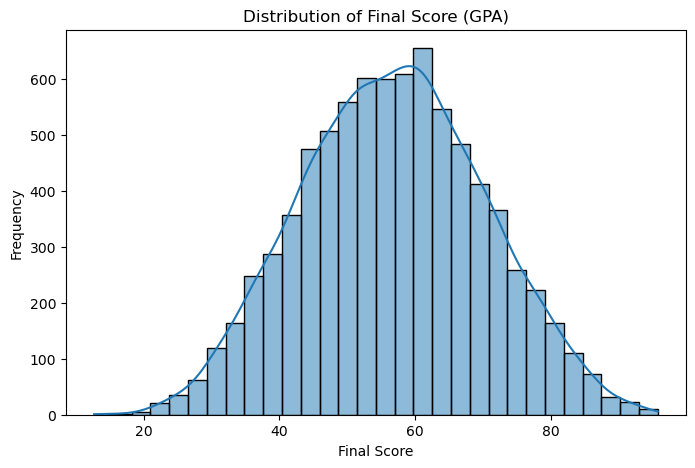

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df2_clean['final_score'], bins=30, kde=True)
plt.title("Distribution of Final Score (GPA)")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

From the Graph we can see it is roughly normal with mean on 56.812

#### Checking AI feature correlation

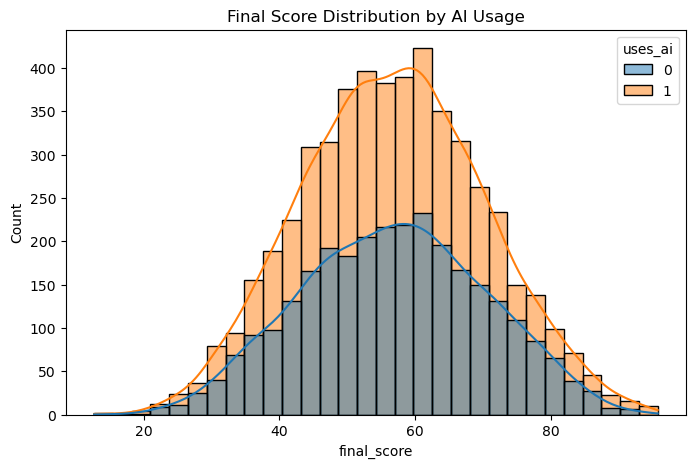

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df2_clean, x='final_score', hue='uses_ai', bins=30, kde=True)
plt.title("Final Score Distribution by AI Usage")
plt.show()

Checking distribution based on 'uses_ai' shows an interesting plot

In [ ]:
X = df2_clean[['uses_ai']]
y = df2_clean['final_score']

X = sm.add_constant(X) 
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.02120
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.884
Time:                        20:18:15   Log-Likelihood:                -32146.
No. Observations:                8000   AIC:                         6.430e+04
Df Residuals:                    7998   BIC:                         6.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.8413      0.251    226.372      0.0

This shows that the feature 'uses_ai' does not have a significant relationship with 'final_score' in this context. We will now check whether AI changes study behaviour.

In [ ]:
X = df2_clean[['ai_dependency_score',
        'ai_generated_content_percentage',
        'ai_prompts_per_week',
        'ai_usage_time_minutes',]]

X = sm.add_constant(X)
y = df2_clean['final_score']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     19.37
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           7.04e-16
Time:                        20:18:15   Log-Likelihood:                -32108.
No. Observations:                8000   AIC:                         6.423e+04
Df Residuals:                    7995   BIC:                         6.426e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

This shows that the strongest predictor in AI usage is 'ai_generated_content_percentage' which affects negatively to the 'final_score'

Just to see, lets check what AI usage does to the other features

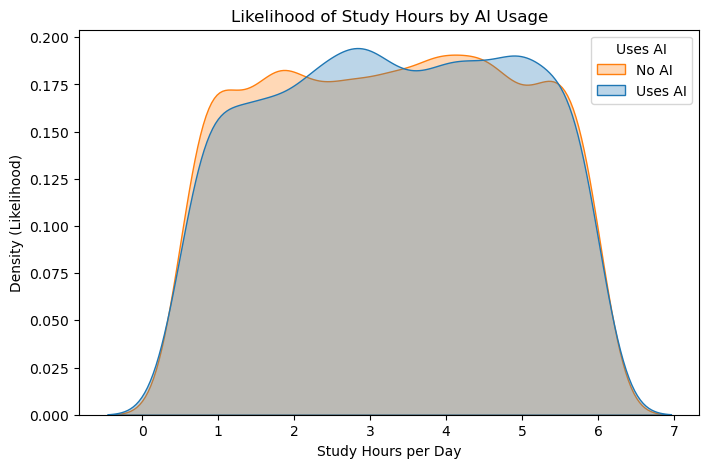

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df2_clean,
    x='study_hours_per_day',
    hue='uses_ai',
    fill=True,
    alpha=0.3,
    common_norm=False
)

plt.title("Likelihood of Study Hours by AI Usage")
plt.xlabel("Study Hours per Day")
plt.ylabel("Density (Likelihood)")
plt.legend(title="Uses AI", labels=["No AI","Uses AI"])
plt.show()

In [ ]:
ai_users = df2_clean[df2_clean['uses_ai'] == 1]['study_hours_per_day']
non_ai_users = df2_clean[df2_clean['uses_ai'] == 0]['study_hours_per_day']

t_stat, p_value = ttest_ind(ai_users, non_ai_users, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.8827400117535221
P-value: 0.37741208912486524


In [ ]:
numeric_cols = df2_clean.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['uses_ai','student_id','ai_usage_time_minutes','ai_dependency_score','ai_generated_content_percentage','ai_prompts_per_week','ai_ethics_score','last_exam_score','assignment_scores_avg','passed'])
numeric_cols

Index(['age', 'study_hours_per_day', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score'],
      dtype='object')

In [ ]:
results = []

ai_users = df2_clean[df2_clean['uses_ai'] == 1]
non_ai_users = df2_clean[df2_clean['uses_ai'] == 0]

for col in numeric_cols:
    
    t_stat, p_value = ttest_ind(
        ai_users[col],
        non_ai_users[col],
        equal_var=False
    )
    
    results.append({
        "feature": col,
        "t_stat": t_stat,
        "p_value": p_value,
        "mean_ai_users": ai_users[col].mean(),
        "mean_non_ai_users": non_ai_users[col].mean()
    })

ttest_results = pd.DataFrame(results)

ttest_results.sort_values("p_value")

,feature,t_stat,p_value,mean_ai_users,mean_non_ai_users
9,class_participation_score,-1.927561,0.053958,5.416732,5.546657
7,social_media_hours,1.746578,0.080762,3.036115,2.965042
2,attendance_percentage,1.473547,0.140656,70.063807,69.474130
4,study_consistency_index,1.415204,0.157061,5.547114,5.461699
6,sleep_hours,1.072349,0.283606,6.477828,6.442166
1,study_hours_per_day,-0.882740,0.377412,3.275293,3.307730
5,improvement_rate,0.669383,0.503277,10.225488,9.952054
0,age,0.571947,0.567379,18.982254,18.940460
8,tutoring_hours,0.421108,0.673692,2.528452,2.514345
3,concept_understanding_score,-0.344732,0.730308,5.476404,5.499652


Seems like the usage of AI does not statistically matter in student habits, albeit this is self-reported data.

## Checking for Demographic differences

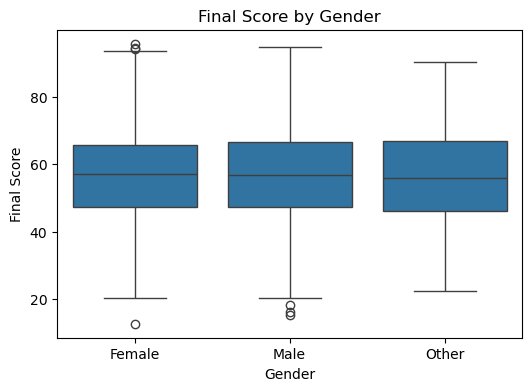

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df2_clean, x='gender', y='final_score')
plt.title("Final Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Final Score")
plt.show()

In [ ]:
df2_clean.groupby('gender')['final_score'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,3811.0,56.840514,13.285915,12.7,47.3,57.0,65.8,95.8
Male,3908.0,56.846878,13.593354,15.4,47.3,56.9,66.6,94.8
Other,281.0,55.939858,13.834823,22.4,46.3,55.8,66.8,90.4


In [ ]:
# simple t-test for gender
male_scores = df2_clean[df2_clean['gender'] == 'Male']['final_score']
female_scores = df2_clean[df2_clean['gender'] == 'Female']['final_score']

ttest_ind(male_scores, female_scores)

TtestResult(statistic=np.float64(0.020795106275032792), pvalue=np.float64(0.9834096391481417), df=np.float64(7717.0))

The data shows that there are much more extremes in the lower end for males and male has a higher std than female, but there are no statistical importance in gender for final_grades

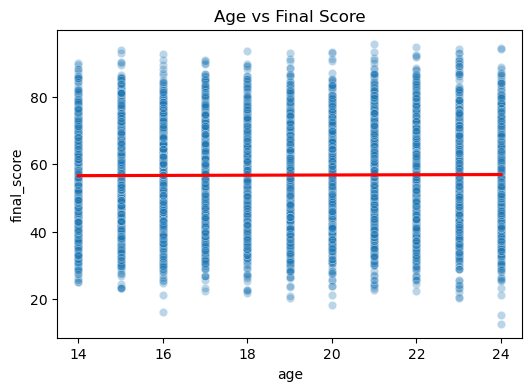

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df2_clean, x='age', y='final_score', alpha=0.3)
sns.regplot(data=df2_clean, x='age', y='final_score', scatter=False, color='red')
plt.title("Age vs Final Score")
plt.show()

In [ ]:
df2_clean.groupby('age')['final_score'].mean().sort_values()

age
14    56.323396
19    56.525729
16    56.538661
18    56.585241
23    56.598806
24    56.752855
15    56.936996
20    57.108832
17    57.149241
22    57.205493
21    57.252661
Name: final_score, dtype: float64

In this data lower grades tend to have a higher mean final_score

In [ ]:
model = ols('final_score ~ C(grade_level)', data=df2_clean).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(grade_level),4.444839e+02,5.0,0.490833,0.783369
Residual,1.447827e+06,7994.0,NaN,NaN


There is no statistical significance in grade_level for this context

# Checking for features with highest predictors for final_score

In [ ]:
drop_cols = [
    'student_id',
    'passed',
    'performance_category',
    'grade_level',
    'gender',
    'last_exam_score',
    'assignment_scores_avg'
]

df_model2 = df2_clean.drop(columns=drop_cols)
df_model2.columns

Index(['age', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score'],
      dtype='object')

In [ ]:
df_model2 = pd.get_dummies(df_model2, drop_first=True)

In [ ]:
X = df_model2.drop(columns=['final_score'])
y = df_model2['final_score']

X = sm.add_constant(X)

In [ ]:
model = sm.OLS(y, X).fit()
print(model.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     118.4
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:22:54   Log-Likelihood:                -31294.
No. Observations:                8000   AIC:                         6.262e+04
Df Residuals:                    7983   BIC:                         6.274e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

An OLS regression was conducted to evaluate predictors of final academic performance. Conceptual understanding was the strongest predictor of final score (β ≈ 1.98, p < 0.001), indicating that deeper mastery of course material substantially improves academic outcomes. AI usage variables such as AI usage time, dependency, and prompt frequency were not statistically significant. However, the percentage of AI-generated assignment content showed a significant negative association with final score (β ≈ −0.048, p < 0.001), suggesting that heavy reliance on AI-generated work may correlate with weaker academic performance.

/var/folders/9h/n79877ts43lb81c738w_z8s80000gn/T/ipykernel_83913/2553156899.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df2_clean.groupby('ai_bin')['final_score'].mean()


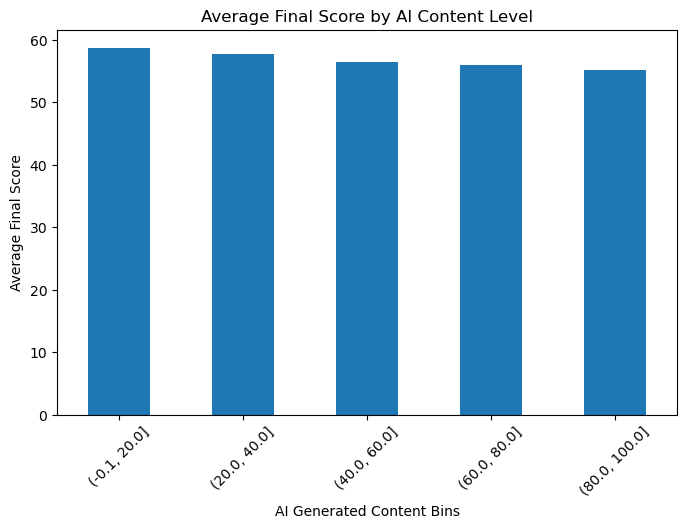

In [ ]:
df2_clean['ai_bin'] = pd.cut(df2_clean['ai_generated_content_percentage'], bins=5)

bin_means = df2_clean.groupby('ai_bin')['final_score'].mean()

plt.figure(figsize=(8,5))
bin_means.plot(kind='bar')

plt.title("Average Final Score by AI Content Level")
plt.xlabel("AI Generated Content Bins")
plt.ylabel("Average Final Score")
plt.xticks(rotation=45)
plt.show()

Graph to show how AI content level influence the average final score


Correlation matrix with final_score:


,final_score
final_score,1.000000
study_hours_per_day,0.015798
social_media_hours,0.004099
class_participation_score,0.003523
attendance_percentage,-0.005182
sleep_hours,-0.005785
study_consistency_index,-0.014126


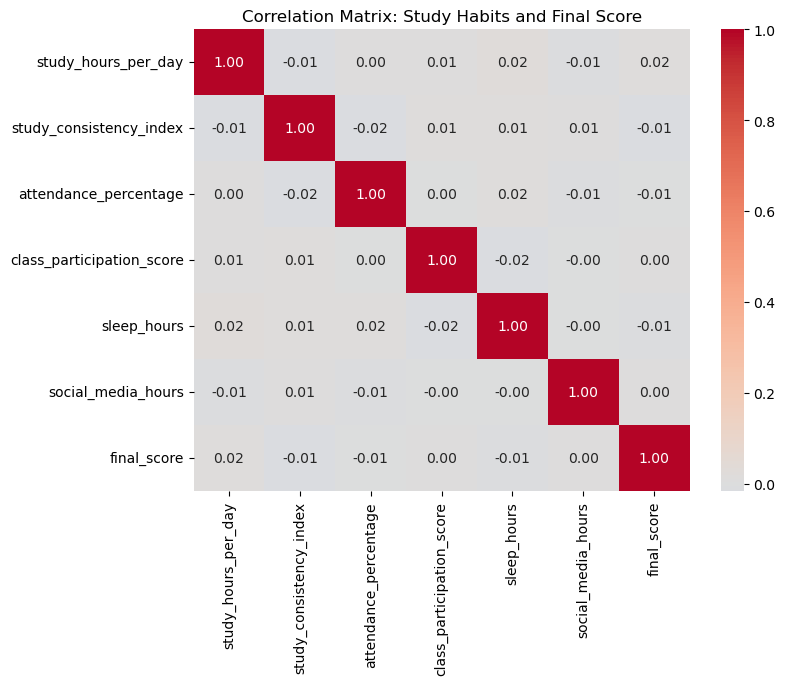

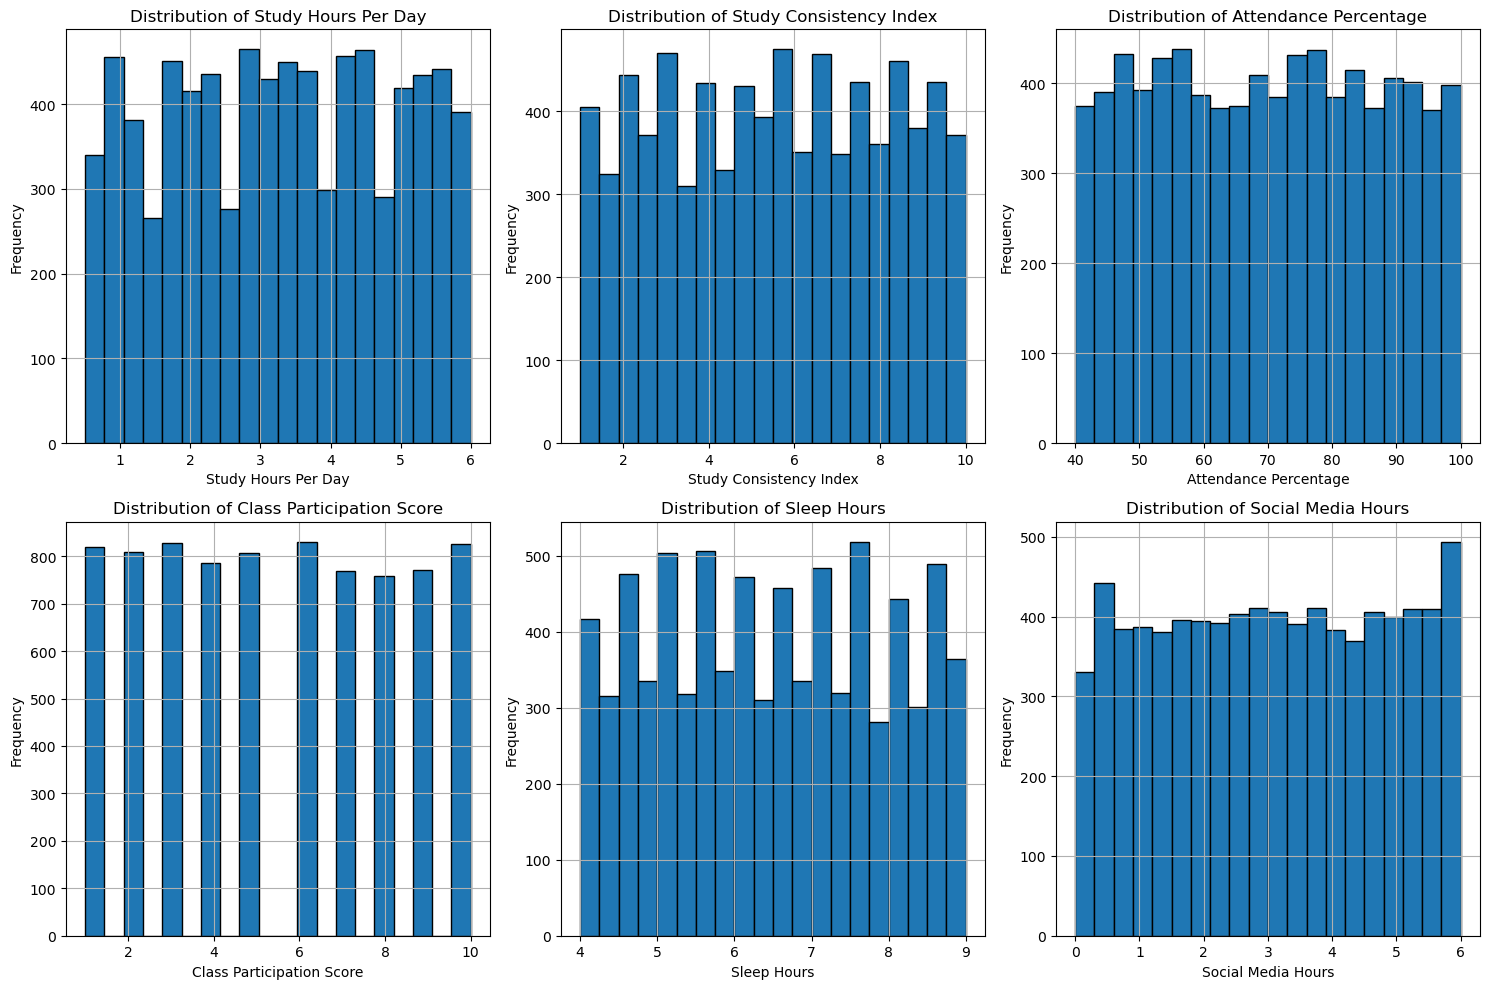

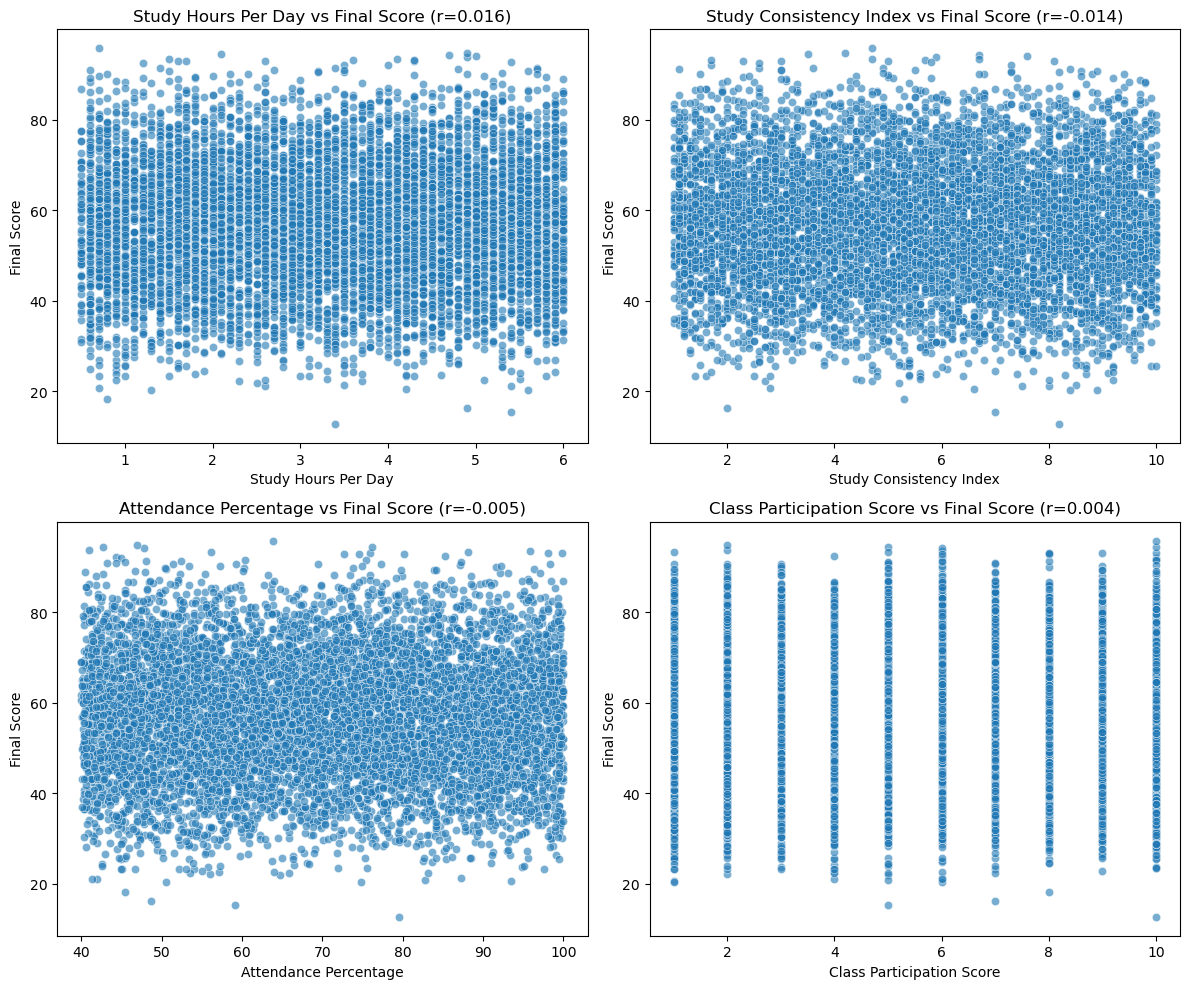

In [ ]:
study_vars = ['study_hours_per_day', 'study_consistency_index', 'attendance_percentage', 
              'class_participation_score', 'sleep_hours', 'social_media_hours']
performance_var = 'final_score'

# Compute correlations
corr_vars = study_vars + [performance_var]
corr_matrix = df2[corr_vars].corr()

print("\nCorrelation matrix with final_score:")
display(corr_matrix[[performance_var]].sort_values(by=performance_var, ascending=False))

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Study Habits and Final Score')
plt.show()

# Distributions of study habits
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for i, var in enumerate(study_vars):
    ax = axes[i//3, i%3]
    df2_clean[var].hist(bins=20, ax=ax, edgecolor='black')
    ax.set_title(f'Distribution of {var.replace("_", " ").title()}')
    ax.set_xlabel(var.replace("_", " ").title())
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Scatter plots for key study habits vs final_score
key_study_vars = ['study_hours_per_day', 'study_consistency_index', 'attendance_percentage', 'class_participation_score']
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for i, var in enumerate(key_study_vars):
    ax = axes[i//2, i%2]
    ax.scatter(df2_clean[var], df2_clean[performance_var], alpha=0.6, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(var.replace("_", " ").title())
    ax.set_ylabel('Final Score')
    ax.set_title(f'{var.replace("_", " ").title()} vs Final Score')
    # Add correlation coefficient to title
    corr_val = df2_clean[var].corr(df2_clean[performance_var])
    ax.set_title(f'{var.replace("_", " ").title()} vs Final Score (r={corr_val:.3f})')
plt.tight_layout()
plt.show()

## Ethics

Our team has carefully considered ethical implications across the full lifecycle of this project, including data collection, storage, analysis, modeling, and potential deployment.

---

### A. Data Collection

#### A.1 Informed Consent — Considered ✓
We will only use publicly available datasets that were collected with appropriate consent for academic research. Dataset documentation will be reviewed to confirm ethical collection practices before any data is used.

#### A.2 Collection Bias — Considered ✓
Survey-based student datasets may contain self-selection bias. Students who choose to participate may differ from those who do not. We acknowledge that this may limit generalizability and will clearly state this limitation in our report.

#### A.3 Limit PII Exposure — Considered ✓
We will only use datasets that are anonymized and do not include personally identifiable information (PII). Identity-level data such as names, emails, or IDs are not necessary for our analysis and will not be used.

#### A.4 Downstream Bias Mitigation — Considered ✓
If demographic variables are included, we will use them carefully to test for fairness rather than to reinforce stereotypes.

---

### B. Data Storage

#### B.1 Data Security — Considered ✓
We will not share raw data beyond what is publicly available from the original source.

#### B.2 Right to Be Forgotten — Considered ✓
Because we are not collecting new data and will only use anonymized public datasets, individual removal requests are not applicable to this project.

#### B.3 Data Retention Plan — Considered ✓
The dataset will only be used for the duration of this course project. We do not plan to retain or reuse the data beyond academic purposes.

---

### C. Analysis

#### C.1 Missing Perspectives — Considered ✓
We recognize that our team may not represent all student experiences. We rely on prior research and will clearly state limitations in interpretation.

#### C.2 Dataset Bias — Considered ✓
We will examine variable distributions and discuss possible biases and potential confounding factors.

#### C.3 Honest Representation — Considered ✓
All visualizations and statistical summaries will accurately represent the data. We will avoid misleading scales and clearly label all figures.

#### C.4 Privacy in Analysis — Considered ✓
We will not display or analyze any personally identifiable information.

#### C.5 Auditability — Considered ✓
All data cleaning and modeling steps will be documented in our notebook to ensure transparency and reproducibility.

---

### D. Modeling

#### D.1 Proxy Discrimination — Considered ✓
We will examine whether any variables may unintentionally act as proxies for protected characteristics and interpret results carefully.

#### D.2 Fairness Across Groups — Considered ✓
We will evaluate whether predictive performance differs across demographic groups.

#### D.3 Metric Selection — Considered ✓
We will use appropriate regression metrics and clearly explain why they were selected.

#### D.4 Explainability — Considered ✓
We will use interpretable methods and explain results in accessible language.

#### D.5 Communicate Limitations — Considered ✓
We will clearly state that our findings demonstrate associations rather than causation, and we will discuss dataset and modeling limitations.

---

### E. Deployment

#### E.1 Monitoring and Evaluation — Considered ✓
This is an academic project and will not be deployed in a real-world setting.

#### E.2 Redress — Considered ✓
Since the model will not be used for real decision-making, direct harm is unlikely.

#### E.3 Roll Back — Considered ✓
The model exists only within our project notebook and can be easily modified or removed.

#### E.4 Unintended Use — Considered ✓
We will clearly state that this model is for educational purposes only and should not be used for high-stakes decisions about students.

## Team Expectations 

Communication: 
- We will meet once per week to discuss progress and assign tasks. 
- We communicate primarily through Discord.
- Members will respond to messages within 24 hours unless they inform the group ahead of time. 
- Important decisions will be written in our group chat, shared document or GitHub repo. 

Work Distribution: 
- Tasks will be divided based on strengths and interests (data cleaning, EDA, modeling, writing, visuals).
- Every member will contribute to both coding and writing. 
- Darts must be shared at least 48 hours before deadlines so everyone can review. 
- No section will be submitted without full group agreement. 

Accountability: 
- Each member is responsible for completing assigned tasks by the agreed deadline. 
- If someone cannot complete their work, they must inform the group as soon as possible.
- If participation becomes uneven, we will address it respectfully and early. 

Conflict Resolution:
- We agree to communicate respectfully, even when we disagree
- If conflicts arise, we will first try to resolve them as a group. 
- If necessary, we will consult a TA for support. 

GitHub & Collaboration: 
- Changes will be clearly labeled with descriptive commit messages. 
- We will not overwrite each other’s work without discussion. 

Academic Integrity: 
- All code and writing will be properly cited. 
- We will not copy from other groups or online submissions. 

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 2/9 (Mon) | 7 PM | Proposal finalized and submitted, dataset downloaded and inspected | Confirm dataset understanding, finalize research variables; assign roles for wrangling, EDA, and analysis |
| 2/16 (Mon) | 7 PM | Data cleaning and preprocessing completed, initial EDA started | Review data quality issues, refine EDA questions, adjust analysis plan if needed |
| 2/23 (Mon) | 7 PM | Finalize EDA; visualizations completed, feature engineering | Discuss findings from EDA, finalize modeling approach and evaluation metrics |
| 3/2 (Mon) | 7 PM | Initial models implemented and evaluated  | Compare models, interpret results, decide on final model(s) |
| 3/9 (Mon) | 7 PM | Final analysis completed, draft results and discussion sections  | Edit and refine analysis narrative, connect results back to hypothesis and literature |
| 3/16 (Mon) | 7 PM | Full project draft completed, ethics and limitations finalized | Final edits, rubric check, prepare figures and tables for submission |
| 3/20 (Fri) | Before 11:59 PM | NA | Turn in Final Project & Group Project Surveys |